# 🧬 Soluble Epoxide Hydrolase (sEH) Inhibitor pIC50 Prediction
## Machine Learning-Based QSAR Modeling for Drug Discovery

---

### ⚠️ IMPORTANT: Run Instructions
1. Run **Cell 1** (Installation) first
2. Go to **Runtime → Restart runtime**
3. Then run all cells starting from **Cell 2**

---

**Target:** CHEMBL1929 (Human sEH)
**Author:** Research Team | **Date:** January 2026

In [ ]:
# ============================================
# FAST INSTALLATION (~1 minute)
# ============================================

!pip install -q --upgrade pip
!pip install -q "numpy<2"
!pip install -q rdkit
!pip install -q chembl_webresource_client
!pip install -q xgboost lightgbm
!pip install -q optuna

# Test
import numpy as np
print(f"✅ NumPy: {np.__version__}")

from rdkit import Chem
mol = Chem.MolFromSmiles('CCO')
print(f"✅ RDKit working!")

print("\n🎉 READY! Run the next cell.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.37.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.90 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have 

In [ ]:
pip install --upgrade numpy pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 121.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 78.0 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.0 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.1 which is incompatible.
gradio 5.50.0 requires pand

In [ ]:
pip install numpy pandas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, MACCSkeys
from rdkit.Chem import Draw
from rdkit.ML.Descriptors import MoleculeDescriptors

from chembl_webresource_client.new_client import new_client

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import xgboost as xgb
import lightgbm as lgb

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported!")


✅ All libraries imported!


---
## 📊 Part 2: Data Collection from ChEMBL

In [ ]:
# Target Information
SEH_CHEMBL_ID = "CHEMBL1929"

print("="*60)
print("TARGET INFORMATION")
print("="*60)
print(f"\n🎯 Target: Human Soluble Epoxide Hydrolase (sEH)")
print(f"   ChEMBL ID: {SEH_CHEMBL_ID}")
print(f"   Gene: EPHX2")
print(f"   UniProt: P34913")
print(f"   EC Number: 3.3.2.10")
print(f"\n💊 Therapeutic Area: Anti-inflammatory, Cardiovascular")

TARGET INFORMATION

🎯 Target: Human Soluble Epoxide Hydrolase (sEH)
   ChEMBL ID: CHEMBL1929
   Gene: EPHX2
   UniProt: P34913
   EC Number: 3.3.2.10

💊 Therapeutic Area: Anti-inflammatory, Cardiovascular


In [ ]:
def fetch_seh_bioactivity_data(target_chembl_id, max_ic50_nm=100000):
    """
    Fetch sEH inhibitor bioactivity data from ChEMBL
    """
    print("\n" + "─"*60)
    print("FETCHING DATA FROM CHEMBL...")
    print("─"*60)

    # Initialize ChEMBL client
    activity = new_client.activity
    target = new_client.target

    # Verify target
    target_info = target.get(target_chembl_id)
    print(f"\n✓ Target found: {target_info['pref_name']}")
    print(f"  Organism: {target_info['organism']}")
    print(f"  Type: {target_info['target_type']}")

    # Query bioactivity data
    print(f"\n🔍 Querying ChEMBL for IC50 data...")

    bioactivities = activity.filter(
        target_chembl_id=target_chembl_id,
        standard_type="IC50",
        standard_relation="=",
        standard_units="nM",
        pchembl_value__isnull=False
    )

    # Convert to DataFrame
    df = pd.DataFrame.from_records(bioactivities)
    print(f"✓ Retrieved {len(df)} bioactivity records")

    if len(df) == 0:
        print("\n✗ No data found!")
        return None

    # Select relevant columns
    cols = [
        'molecule_chembl_id', 'canonical_smiles',
        'standard_value', 'standard_units', 'standard_type',
        'pchembl_value', 'assay_chembl_id', 'assay_type',
        'confidence_score', 'document_year'
    ]

    available_cols = [c for c in cols if c in df.columns]
    df = df[available_cols].copy()

    # Apply IC50 filter
    df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
    df = df[df['standard_value'] <= max_ic50_nm]

    print(f"✓ After filtering IC50 ≤ {max_ic50_nm} nM: {len(df)} records")

    return df

# Fetch data
df_raw = fetch_seh_bioactivity_data(
    target_chembl_id=SEH_CHEMBL_ID,
    max_ic50_nm=100000
)

if df_raw is not None:
    print(f"\n📈 Dataset Statistics:")
    print(f"   Total records: {len(df_raw)}")
    print(f"   Unique compounds: {df_raw['molecule_chembl_id'].nunique()}")
    display(df_raw.head())


────────────────────────────────────────────────────────────
FETCHING DATA FROM CHEMBL...
────────────────────────────────────────────────────────────

✓ Target found: Xanthine dehydrogenase/oxidase
  Organism: Homo sapiens
  Type: SINGLE PROTEIN

🔍 Querying ChEMBL for IC50 data...
✓ Retrieved 772 bioactivity records
✓ After filtering IC50 ≤ 100000 nM: 772 records

📈 Dataset Statistics:
   Total records: 772
   Unique compounds: 620


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_type,pchembl_value,assay_chembl_id,assay_type,document_year
0,CHEMBL64616,CCCCCCNc1nc(O)c2[nH]cnc2n1,30500.0,nM,IC50,4.52,CHEMBL823474,B,1996
1,CHEMBL64616,CCCCCCNc1nc(O)c2[nH]cnc2n1,30500.0,nM,IC50,4.52,CHEMBL823474,B,1996
2,CHEMBL86056,CCCCCCSc1nc(O)c2[nH]cnc2n1,115.0,nM,IC50,6.94,CHEMBL823474,B,1996
3,CHEMBL86021,CCCCCSc1nc(O)c2[nH]cnc2n1,2850.0,nM,IC50,5.54,CHEMBL823474,B,1996
4,CHEMBL84609,CCCCSc1nc(O)c2[nH]cnc2n1,3880.0,nM,IC50,5.41,CHEMBL823474,B,1996


---
## 🧹 Part 3: Data Preprocessing

In [ ]:
def preprocess_bioactivity_data(df):
    """
    Comprehensive preprocessing of sEH bioactivity data
    """
    print("\n" + "="*60)
    print("DATA PREPROCESSING PIPELINE")
    print("="*60)

    df_clean = df.copy()
    print(f"\n📊 Starting with {len(df_clean)} records")

    # Step 1: Remove missing SMILES
    print("\n[1/6] Removing missing SMILES...")
    df_clean = df_clean.dropna(subset=['canonical_smiles'])
    print(f"    → {len(df_clean)} records remaining")

    # Step 2: Remove missing IC50
    print("\n[2/6] Removing missing IC50 values...")
    df_clean = df_clean.dropna(subset=['standard_value'])
    df_clean['standard_value'] = pd.to_numeric(df_clean['standard_value'], errors='coerce')
    df_clean = df_clean.dropna(subset=['standard_value'])
    print(f"    → {len(df_clean)} records remaining")

    # Step 3: Filter by confidence score
    print("\n[3/6] Filtering by confidence score (≥7)...")
    if 'confidence_score' in df_clean.columns:
        before = len(df_clean)
        df_clean = df_clean[df_clean['confidence_score'] >= 7]
        print(f"    → {len(df_clean)} records (removed {before - len(df_clean)})")

    # Step 4: Calculate pIC50
    print("\n[4/6] Calculating pIC50 values...")
    if 'pchembl_value' in df_clean.columns:
        df_clean['pic50'] = pd.to_numeric(df_clean['pchembl_value'], errors='coerce')
    else:
        df_clean['pic50'] = -np.log10(df_clean['standard_value'] * 1e-9)

    df_clean = df_clean.dropna(subset=['pic50'])
    print(f"    → pIC50 range: {df_clean['pic50'].min():.2f} to {df_clean['pic50'].max():.2f}")

    # Step 5: Handle duplicates
    print("\n[5/6] Handling duplicate compounds...")
    df_clean = df_clean.groupby('canonical_smiles').agg({
        'molecule_chembl_id': 'first',
        'pic50': 'mean',
        'standard_value': 'mean'
    }).reset_index()
    print(f"    → {len(df_clean)} unique compounds")

    # Step 6: Validate SMILES
    print("\n[6/6] Validating chemical structures...")
    def is_valid_smiles(smiles):
        try:
            mol = Chem.MolFromSmiles(smiles)
            return mol is not None
        except:
            return False

    df_clean['valid'] = df_clean['canonical_smiles'].apply(is_valid_smiles)
    invalid = (~df_clean['valid']).sum()
    df_clean = df_clean[df_clean['valid']].drop('valid', axis=1)
    print(f"    → Removed {invalid} invalid SMILES")
    print(f"    → {len(df_clean)} valid compounds")

    print("\n" + "─"*60)
    print(f"✅ PREPROCESSING COMPLETE: {len(df_clean)} compounds")
    print("─"*60)

    return df_clean

# Apply preprocessing
df_processed = preprocess_bioactivity_data(df_raw)


DATA PREPROCESSING PIPELINE

📊 Starting with 772 records

[1/6] Removing missing SMILES...
    → 768 records remaining

[2/6] Removing missing IC50 values...
    → 768 records remaining

[3/6] Filtering by confidence score (≥7)...

[4/6] Calculating pIC50 values...
    → pIC50 range: 4.01 to 10.82

[5/6] Handling duplicate compounds...
    → 616 unique compounds

[6/6] Validating chemical structures...
    → Removed 0 invalid SMILES
    → 616 valid compounds

────────────────────────────────────────────────────────────
✅ PREPROCESSING COMPLETE: 616 compounds
────────────────────────────────────────────────────────────


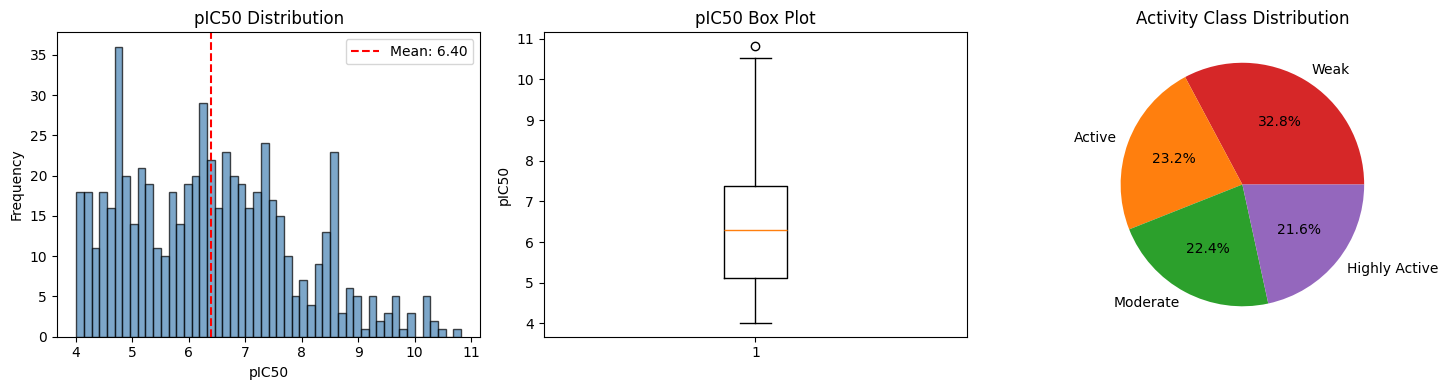


📊 Activity Class Breakdown:
   Weak: 202 compounds (32.8%)
   Active: 143 compounds (23.2%)
   Moderate: 138 compounds (22.4%)
   Highly Active: 133 compounds (21.6%)


In [ ]:
# Visualize pIC50 distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histogram
axes[0].hist(df_processed['pic50'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_processed['pic50'].mean(), color='red', linestyle='--', label=f'Mean: {df_processed["pic50"].mean():.2f}')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Frequency')
axes[0].set_title('pIC50 Distribution')
axes[0].legend()

# Box plot
axes[1].boxplot(df_processed['pic50'], vert=True)
axes[1].set_ylabel('pIC50')
axes[1].set_title('pIC50 Box Plot')

# Activity classes
def classify_activity(pic50):
    if pic50 > 7.5: return 'Highly Active'
    elif pic50 > 6.5: return 'Active'
    elif pic50 > 5.5: return 'Moderate'
    else: return 'Weak'

df_processed['activity_class'] = df_processed['pic50'].apply(classify_activity)
activity_counts = df_processed['activity_class'].value_counts()
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd']
axes[2].pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', colors=colors)
axes[2].set_title('Activity Class Distribution')

plt.tight_layout()
plt.show()

print("\n📊 Activity Class Breakdown:")
for cls, count in activity_counts.items():
    print(f"   {cls}: {count} compounds ({count/len(df_processed)*100:.1f}%)")

---
## 🧪 Part 4: Molecular Descriptor Calculation

In [ ]:
def calculate_molecular_descriptors(smiles_list):
    """
    Calculate molecular descriptors and fingerprints
    """
    print("\n" + "="*60)
    print("CALCULATING MOLECULAR DESCRIPTORS")
    print("="*60)

    # Convert SMILES to molecules
    print("\n[1/3] Converting SMILES to molecules...")
    mols = [Chem.MolFromSmiles(smi) for smi in smiles_list]
    print(f"    ✓ {len(mols)} molecules generated")

    # Calculate 2D descriptors
    print("\n[2/3] Calculating 2D descriptors...")
    descriptor_names = [
        'MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors',
        'NumRotatableBonds', 'NumAromaticRings', 'TPSA',
        'NumHeteroatoms', 'RingCount', 'FractionCSP3',
        'NumAliphaticRings', 'NumSaturatedRings'
    ]

    calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

    descriptors_2d = []
    for mol in mols:
        if mol is not None:
            desc = calc.CalcDescriptors(mol)
            descriptors_2d.append(desc)
        else:
            descriptors_2d.append([np.nan] * len(descriptor_names))

    df_descriptors = pd.DataFrame(descriptors_2d, columns=descriptor_names)
    print(f"    ✓ {len(descriptor_names)} 2D descriptors calculated")

    # Calculate Morgan fingerprints (ECFP4)
    print("\n[3/3] Calculating fingerprints...")
    morgan_fps = []
    for mol in mols:
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
            morgan_fps.append(list(fp))
        else:
            morgan_fps.append([0] * 1024)

    morgan_cols = [f'Morgan_{i}' for i in range(1024)]
    df_morgan = pd.DataFrame(morgan_fps, columns=morgan_cols)
    print(f"    ✓ Morgan fingerprints (1024 bits) calculated")

    # Combine all
    df_all = pd.concat([df_descriptors, df_morgan], axis=1)

    print("\n" + "─"*60)
    print(f"✅ Total features: {df_all.shape[1]}")
    print("─"*60)

    return df_all

# Calculate descriptors
X_descriptors = calculate_molecular_descriptors(df_processed['canonical_smiles'].tolist())

print("\n📊 Descriptor Statistics:")
display(X_descriptors.iloc[:, :12].describe())


CALCULATING MOLECULAR DESCRIPTORS

[1/3] Converting SMILES to molecules...
    ✓ 616 molecules generated

[2/3] Calculating 2D descriptors...
    ✓ 12 2D descriptors calculated

[3/3] Calculating fingerprints...


[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerat

    ✓ Morgan fingerprints (1024 bits) calculated

────────────────────────────────────────────────────────────
✅ Total features: 1036
────────────────────────────────────────────────────────────

📊 Descriptor Statistics:


[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerator
[05:10:25] DEPRECATION WARNING: please use MorganGenerat

,MolWt,MolLogP,NumHDonors,NumHAcceptors,NumRotatableBonds,NumAromaticRings,TPSA,NumHeteroatoms,RingCount,FractionCSP3,NumAliphaticRings,NumSaturatedRings
count,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000,616.000000
mean,340.758037,2.439431,2.560065,5.647727,3.777597,2.706169,104.394886,7.472403,3.009740,0.157192,0.303571,0.214286
std,97.246938,1.558084,1.892122,2.410194,1.971558,0.779636,42.853769,2.729404,0.912373,0.157969,0.894638,0.804170
min,135.130000,-3.009100,0.000000,1.000000,0.000000,0.000000,8.810000,2.000000,1.000000,0.000000,0.000000,0.000000
25%,286.682000,1.382980,1.000000,4.000000,2.000000,2.000000,79.195000,6.000000,3.000000,0.047619,0.000000,0.000000
50%,329.381000,2.585200,2.000000,5.000000,4.000000,3.000000,96.100000,7.000000,3.000000,0.111111,0.000000,0.000000
75%,376.295750,3.543695,3.000000,6.000000,5.000000,3.000000,124.522500,9.000000,3.000000,0.250000,0.000000,0.000000
max,1189.349000,7.578300,14.000000,25.000000,16.000000,6.000000,392.590000,25.000000,10.000000,0.975610,10.000000,9.000000


In [ ]:
# Feature preprocessing
print("="*60)
print("FEATURE PREPROCESSING")
print("="*60)

# Remove constant features
print("\n[1/2] Removing constant features...")
variance = X_descriptors.var()
constant_features = variance[variance == 0].index.tolist()
X_descriptors = X_descriptors.drop(columns=constant_features)
print(f"    → Removed {len(constant_features)}, remaining: {X_descriptors.shape[1]}")

# Handle missing values
print("\n[2/2] Handling missing values...")
X_descriptors = X_descriptors.fillna(X_descriptors.mean())
print(f"    → Filled with column means")

print(f"\n✅ Final feature matrix: {X_descriptors.shape}")

FEATURE PREPROCESSING

[1/2] Removing constant features...
    → Removed 63, remaining: 973

[2/2] Handling missing values...
    → Filled with column means

✅ Final feature matrix: (616, 973)


---
## 📊 Part 5: Train/Test Split

In [ ]:
# Prepare X and y
X = X_descriptors.values
y = df_processed['pic50'].values

print("="*60)
print("TRAIN/VALIDATION/TEST SPLIT")
print("="*60)

# Split data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=RANDOM_STATE
)

print(f"\n📊 Dataset Split:")
print(f"   Training: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Features standardized")

TRAIN/VALIDATION/TEST SPLIT

📊 Dataset Split:
   Training: 430 (69.8%)
   Validation: 93 (15.1%)
   Test: 93 (15.1%)

✅ Features standardized


---
## 🤖 Part 6: Model Training

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 53.2 MB/s  0:00:01


In [ ]:
from catboost import CatBoostRegressor
# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

results = {}
models = {}

print("="*60)
print("TRAINING MODELS")
print("="*60)

# 1. Ridge Regression
print("\n[1/5] Training Ridge Regression...")
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_val_scaled)
results['Ridge'] = evaluate_model(y_val, y_pred, 'Ridge')
models['Ridge'] = ridge

# 2. Random Forest
print("\n[2/5] Training Random Forest...")
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_val_scaled)
results['Random Forest'] = evaluate_model(y_val, y_pred, 'Random Forest')
models['Random Forest'] = rf

# 3. XGBoost
print("\n[3/5] Training XGBoost...")
xgboost = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE, n_jobs=-1)
xgboost.fit(X_train_scaled, y_train)
y_pred = xgboost.predict(X_val_scaled)
results['XGBoost'] = evaluate_model(y_val, y_pred, 'XGBoost')
models['XGBoost'] = xgboost

# 4. LightGBM
print("\n[4/5] Training LightGBM...")
lightgbm = lgb.LGBMRegressor(n_estimators=100, max_depth=10, learning_rate=0.1, random_state=RANDOM_STATE, verbose=-1)
lightgbm.fit(X_train_scaled, y_train)
y_pred = lightgbm.predict(X_val_scaled)
results['LightGBM'] = evaluate_model(y_val, y_pred, 'LightGBM')
models['LightGBM'] = lightgbm

# 5. CatBoost
print("\n[5/5] Training CatBoost...")
catboost = CatBoostRegressor(iterations=100, depth=6, learning_rate=0.1, random_state=RANDOM_STATE, verbose=0)
catboost.fit(X_train_scaled, y_train)
y_pred = catboost.predict(X_val_scaled)
results['CatBoost'] = evaluate_model(y_val, y_pred, 'CatBoost')
models['CatBoost'] = catboost

print("\n" + "="*60)
print("✅ ALL MODELS TRAINED")
print("="*60)

TRAINING MODELS

[1/5] Training Ridge Regression...

Ridge: RMSE=1.1467, MAE=0.8482, R²=0.4297

[2/5] Training Random Forest...

Random Forest: RMSE=0.6241, MAE=0.4334, R²=0.8311

[3/5] Training XGBoost...

XGBoost: RMSE=0.6222, MAE=0.4347, R²=0.8321

[4/5] Training LightGBM...

LightGBM: RMSE=0.6304, MAE=0.4469, R²=0.8276

[5/5] Training CatBoost...

CatBoost: RMSE=0.6680, MAE=0.5003, R²=0.8065

✅ ALL MODELS TRAINED


MODEL COMPARISON

                   RMSE       MAE        R2
XGBoost        0.622230  0.434669  0.832078
Random Forest  0.624086  0.433390  0.831075
LightGBM       0.630395  0.446934  0.827642
CatBoost       0.667986  0.500281  0.806473
Ridge          1.146722  0.848169  0.429675


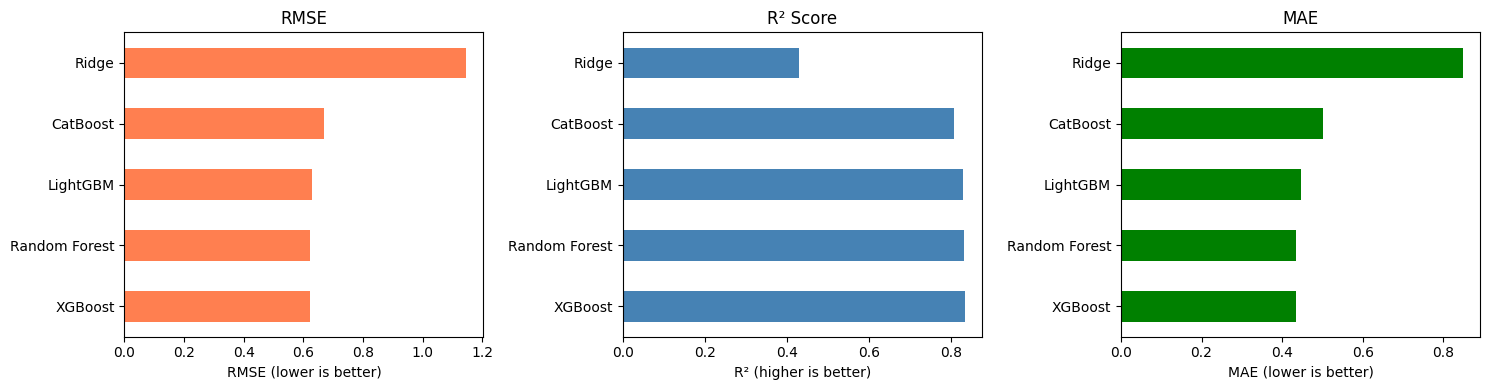


🏆 BEST MODEL: XGBoost (R² = 0.8321)


In [ ]:
# Compare models
print("="*60)
print("MODEL COMPARISON")
print("="*60)

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print("\n" + results_df.to_string())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

results_df['RMSE'].plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('RMSE')

results_df['R2'].plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('R² Score')

results_df['MAE'].plot(kind='barh', ax=axes[2], color='green')
axes[2].set_xlabel('MAE (lower is better)')
axes[2].set_title('MAE')

plt.tight_layout()
plt.show()

# Best model
best_name = results_df.index[0]
best_model = models[best_name]
print(f"\n🏆 BEST MODEL: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")

FINAL TEST EVALUATION: XGBoost

XGBoost (Test Set): RMSE=0.6182, MAE=0.4783, R²=0.8127


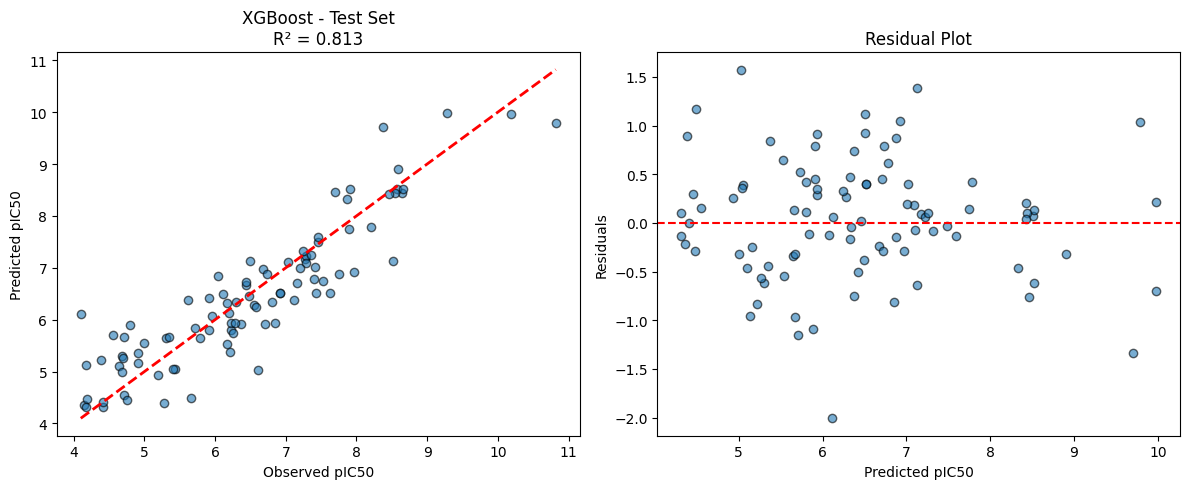


✅ Final evaluation complete!


In [ ]:
# Final evaluation on test set
print("="*60)
print(f"FINAL TEST EVALUATION: {best_name}")
print("="*60)

y_test_pred = best_model.predict(X_test_scaled)
test_results = evaluate_model(y_test, y_test_pred, f'{best_name} (Test Set)')

# Scatter plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolor='black')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[0].set_xlabel('Observed pIC50')
ax[0].set_ylabel('Predicted pIC50')
ax[0].set_title(f'{best_name} - Test Set\nR² = {test_results["R2"]:.3f}')

# Residuals
residuals = y_test - y_test_pred
ax[1].scatter(y_test_pred, residuals, alpha=0.6, edgecolor='black')
ax[1].axhline(y=0, color='r', linestyle='--')
ax[1].set_xlabel('Predicted pIC50')
ax[1].set_ylabel('Residuals')
ax[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print("\n✅ Final evaluation complete!")

---
## 💾 Part 7: Save Model

In [ ]:
import joblib
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model
model_file = f'seh_model_{best_name.replace(" ", "_")}_{timestamp}.pkl'
joblib.dump(best_model, model_file)
print(f"✅ Model saved: {model_file}")

# Save scaler
scaler_file = f'seh_scaler_{timestamp}.pkl'
joblib.dump(scaler, scaler_file)
print(f"✅ Scaler saved: {scaler_file}")

# Save results
results_df.to_csv(f'seh_results_{timestamp}.csv')
print(f"✅ Results saved")

print("\n" + "="*60)
print("🎉 PIPELINE COMPLETE!")
print("="*60)
print(f"\nBest Model: {best_name}")
print(f"Test R²: {test_results['R2']:.4f}")
print(f"Test RMSE: {test_results['RMSE']:.4f}")

NameError: name 'best_name' is not defined

In [ ]:
# Save feature names used for training
feature_names = X_descriptors.columns.tolist()  # X_descriptors from Part 4/5

feature_file = 'seh_features_20260130_051249.txt'  # match your timestamp
with open(feature_file, 'w') as f:
    for name in feature_names:
        f.write(name + '\n')

print("Feature names saved to:", feature_file)

Feature names saved to: seh_features_20260130_051249.txt


In [ ]:
import pandas as pd

# X is the feature matrix used for model training
pd.Series(X.columns).to_csv("descriptor_list.csv", index=False)


NameError: name 'X_descriptors' is not defined

In [ ]:
for var in list(globals().keys()):
    obj = globals()[var]
    if hasattr(obj, "columns") and isinstance(obj, (pd.DataFrame, pd.Series)):
        print(var, obj.shape)

In [1]:
import numpy as np

# Example predicted IC50 values (in nM)
predicted_IC50 = [100, 500, 1000, 10, 5000]  # Example in nM

# Check if the values are within typical pIC50 range (4 to 10)
if np.all(np.array(predicted_IC50) >= 4) and np.all(np.array(predicted_IC50) <= 10):
    print("The model is predicting pIC50.")
else:
    print("The model is predicting IC50.")

    # Convert IC50 to pIC50 (for verification or comparison)
    predicted_pIC50 = -np.log10(np.array(predicted_IC50) * 1e-9)  # Converting from nM to pIC50
    print("Converted pIC50 values:", predicted_pIC50)


The model is predicting IC50.
Converted pIC50 values: [7.      6.30103 6.      8.      5.30103]
